$$
 \newcommand{d}{\,{\rm d}}
 \def\vc#1{\mathbf{\boldsymbol{#1}}}     % vector
 \def\tn#1{{\mathbb{#1}}}
 \def\Real{{\rm\bf R}}
$$

## Existence and uniqueness of solutions
As we have already mentioned, with a known initial position, the balloon will have a definite trajectory in reality.
However, the ODE system of its motion is only a model for the movement of the balloon and therefore nothing can be deduced from physical reality about its properties. On the contrary, we should prove that the equation poses a
unique solution (which is a term we first need to define) to verify that our model is correctly postulated. This is neccessary yet not sufficient condition for a model to be a correct one. In this chapter, we will show under what conditions there exists 
a solution to the 1st order equation a
under what conditions is this solution unambiguous. Finally, we will see that this retroactively refines our physical considerations about the balloon.



### Existence of the solution, Peano theorem

---

**[Peano existence theorem](https://en.wikipedia.org/wiki/Peano_existence_theorem)**.

Let the initial value problem be given

$$
  \dot{\vc x}=\vc f(t,\vc x),\qquad\vc x(\tau)=\vc \xi,
$$

where the function $\vc f$ is **continuous** on the set $I \times H \subset \Real \times \Real^n$, which contains the starting point $X_0=( \tau, \vc \xi)$.
Then there **exists a solution** of the problem  on the neighborhood $J \subset I$ of the point $\tau$.

---

Peano theorem gives us the existence of a solution only on a small neighborhood of the initial time, say on the closed interval $J_0=\langle \tau-\epsilon, \tau + \epsilon \rangle$
(note that the solution exists even before the initial time). For the end point, we can apply Peano theorem again and thus extend the solution: if $\tau + \epsilon \in I$
and $\vc x(\tau + \epsilon) \in H$, then the solution exists on the larger interval $J_1 = \langle \tau - \epsilon, \tau + \epsilon + \delta$. In this way, we can extend the solution until it leaves us with a set where the function $\vc f$ is continuous, i.e., $I \times H$. This gives us *maximum solution interval*, i.e. the longest interval on which a solution to the initial value problem exists. Solution on the maximum interval
we call *maximum solution*.



**Example:**
$$
x'(t) = x^2, \quad x(0)=1
$$

See the aerodynamic break example for the solution: 
$$
x(t) = \frac{1}{1-t}
$$
The solution leaves $H = \Real$ in finite time $t=1$, can not be prolongeted beyond that point. 

### On continuity of functions on $\Real^n$

Function is continuous if $f(x_0) = lim_{x\to x_0} f(x)$ however for function of more then one variable, e.g. $f(x, y)$, the $\vc{X}=(x, y)$ can aproach 
$\vc{X}_0=(x_0, y_0)$ following different trajectories and the limit can depend on the trajectory. Consider function:

$$
    f(x,y) = \frac{xy}{x^2 +y^2}.
$$


for $y=0$ it reduces to $f(x,0) = 0$ which is continuous function of $x$ with value $f=0$ at $x=0$.
Same, if we approach origin along the line $x=0$. But for the line $ (x, y) = (t, t)$ the function is 
$f(x,y) = \frac{t^2}{2t^2}= \frac12$ so the limit for $t \to 0$ is different and the function is not continuous at the origin.

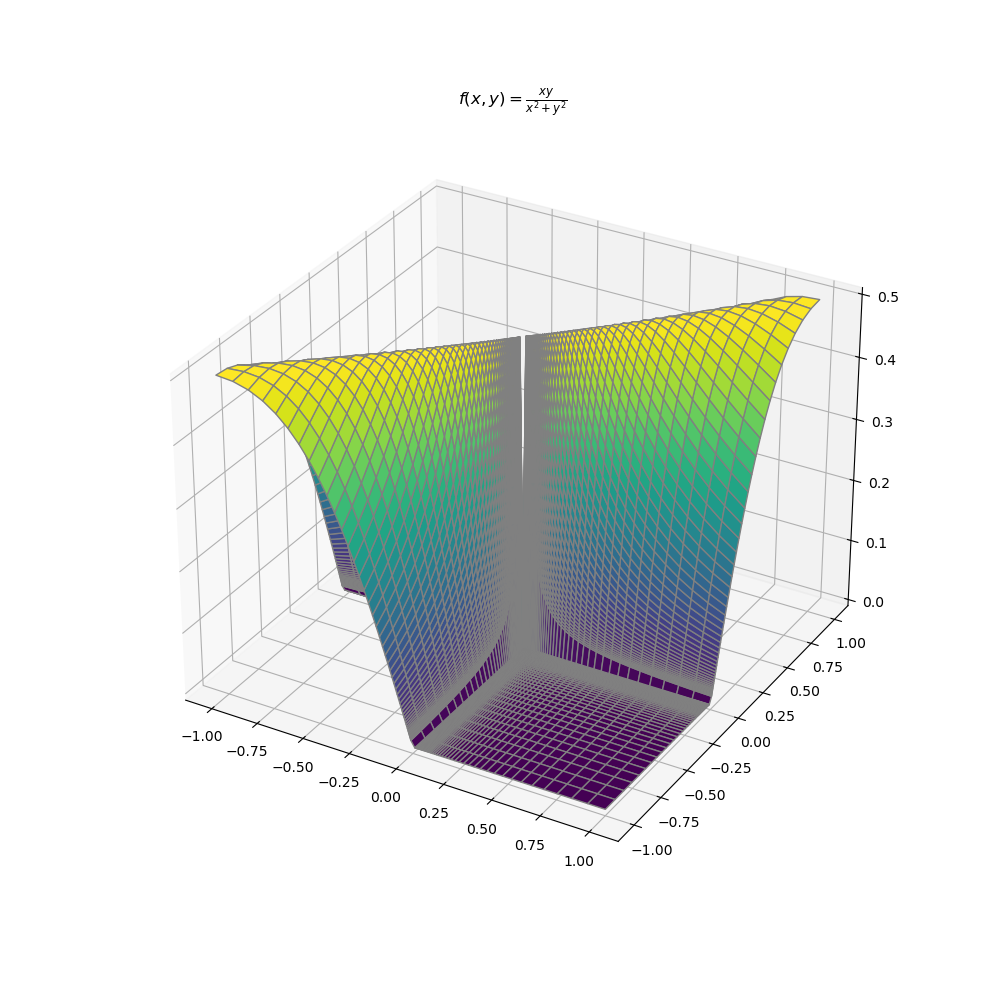

In [1]:
%matplotlib widget
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')

x = np.logspace(-2, 0, 50)
x = np.array([*(-x[::-1]),  *x])
y = x

X, Y = np.meshgrid(x, y)
Z = np.maximum(X*Y/(X**2 + Y**2), 0)

ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
                cmap='viridis', edgecolor='gray')
ax.set_title("$f(x,y) = \\frac{xy}{x^2 +y^2}$");


### Uniqueness of the solution
Furthermore, we will be interested in the conditions under which the solution not only exists, but is also unique.

**Example of non-unique solution**

Consider the equation

$$
 x' = 2\sqrt{|x|}.
$$

the right-hand side is continuous on the entire $\Real$ so the solution exists and can be arbitrarly prolongated. The equation has infinitely many solutions consisting of the following three branches:

- $x(t)=0$
- $x(t)= +(C + t)^2$
- $x(t)= -(C - t)^2$

The first is trivial, let's check the other two:

$$
    x' = (\pm (C \pm t)^2)' = \pm 2(c\pm t) (\pm 1) = 2(C \pm t)
$$

$$
   2\sqrt{|x|} = 2\sqrt{|\pm (C \pm t)^2|} = 2(C\pm t).
$$

When extending the solution of branch 1 to the right, at any point we can choose whether to continue with branch 1 or branch 2, similarly when extending to the left, we can 
switch to branch 3 at any point. So there are infinitely many solutions. 

**Non-unique models**
Usualy, the models describing physical processes should have unique solution, however there
some notable examples of processes where it is not the case. First, consider a light particle moving friction-less on a surface given by function $z(x)= x^{3/2}$. are few cases where it 


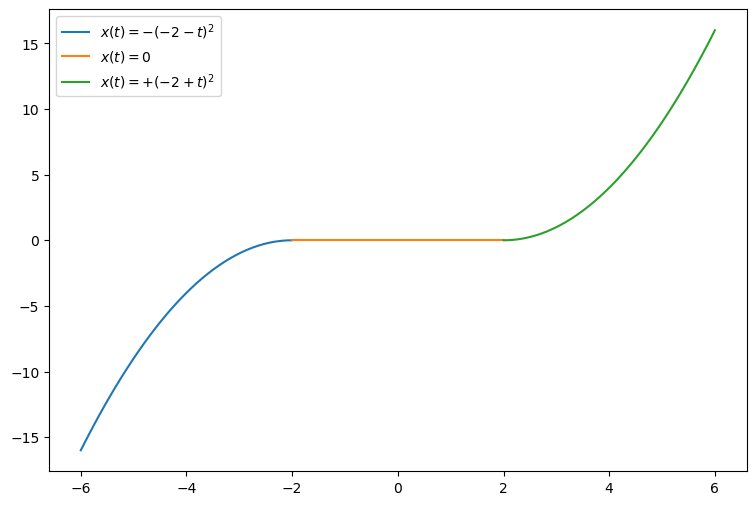

In [1]:
import matplotlib.pyplot as plt
import numpy as np

C1 = -2
C2 = 2

fig, (ax) = plt.subplots(figsize=(9,6), dpi=100)
t_a = np.linspace(C1 - 4, C1, 50)
t_b = np.linspace(C1, C2)
t_c = np.linspace(C2, C2 + 4, 50)
ax.plot(t_a, -(C1 - t_a)**2, label = f"$x(t) = -({C1} - t)^2$")
ax.plot(t_b, np.zeros_like(t_b), label = f"$x(t) = 0$")
ax.plot(t_c, (-C2 + t_c)**2, label = f"$x(t) = +(-{C2} + t)^2$")
ax.legend()

### Definition of unique solution
We say that an inital value problem has a unique solution on the interval $J \subset I$ if any two solutions $\vc x_1(t)$ and $\vc x_2(t)$ on the interval $J$ coincide on this interval, i.e. $\vc x_1(t) = \vc x_2(t)$ holds for all times $t\in J$.


### Lipchitz function

From the example, it can be seen that the ambiguity of the solution is only at the point $x=0$, which is special because there the function has an undefined (infinite)
 derivative $f(x) = \sqrt{|x|}$. We will now introduce a class of functions that do not suffer from this problem and for which we get a unique solution.


Let $I\times H$ be a domain in $\Real \times \Real^n$. The vector function $\vc f:I \times H\to \Real^n$ is called *Lipchitz* with respect to the variable $\vc x$ on the set $I\times H$ if there exists a positive constant $L$ such that
for each time $t\in I$ and pair of points $\vc x$, $\vc y$ in $H$ it holds:

$$
    \|\vc f(t,\vc x)- \vc f(t,\vc y)\| \leq L \|\vc x-\vc y\|.
$$

If we want to emphasize the value of the constant $L$, we say that the function is Lipchitz with constant $L$.
We can use any norm $\|\cdot\|$ on the space $\Real^n$, because
all norms on finite dimensional spaces are equivalent. However, the value of the constant $L$ depends on the choice of norm, the Eucleid norm $\|\vc x\|_2 = \sqrt{\vc x \cdot \vc x}$ is the standard choice.

**Functions with bounded derivative.**

An important class of Lipschitz functions are functions of bounded first derivatives, called also $C^1$ functions. Let's try to prove it. We use the maximum norm 
$\|\vc x\|_{\infty} = max_{i} |x_i|$. Let us have a function $\vc f: I \times H \to \Real^n$
with limited partial derivatives:

$$
    \Big\| \frac{\partial f}{\partial x_i}(t, \vc x) \Big\| \le M, \quad \text{for all } t\in I,\ \vc x \in H,\ i=1,\dots, n
$$

Now let's have an arbitrary one time $t\in I$ and arbitrary points $\vc x,\, \vc y\in H$. For the function $f_i$, we construct the function
on the segment connecting the points $\vc x$ and $\vc y$:

$$
   g_i(s) = f_i(t, \vc z(s)),\quad \vc z(s) = (1-s) \vc x + s \vc y.
$$

For its derivative:
$$
  g_i'(s) = \nabla f_i(t, z) \cdot (\vc y - \vc x) 
  = \sum_{j=1}^{n} \frac{\partial f_i}{\partial x_j}( t, \vc z(s)) (y_j - x_j)
$$


According to the mean value theorem, for every function $g_i$, $i=1,2,\dots,n$,
point $s_i\in \langle 0, 1\rangle$ such that it holds

$$
    f_i(t, \vc x)-f_i(t, \vc y)= g_i(0) - g_i(1) = g_i'(s_0).
$$
The point $s_i$ corresponds to the point $z_i = z(s_i)$, by combining the last two relations we get

$$
  |f(t, \vc x)-f(t, \vc y)| = |g_i'(s_0)| 
  \le \sum_{j=1}^{n} \Big | \frac{\partial f_i}{\partial x_j}(t, \vc z(s_i)) \Big | 
  |y_j - x_j| \le M\|y - x\|.
$$

Now we sum over $i$ and get:

$$
  \|\vc f(t, \vc x) - \vc f(t,\vc y) \| \le nM \|y-x\|.
$$
By which we proved that $\vc f$ is Lipchitz on $I\times H$ with respect to $\vc x$ with constant $nM$.


---

**[Picard Theorem (Existence and Uniqueness)](https://en.wikipedia.org/wiki/Picard%E2%80%93Lindel%C3%B6f_theorem)**


Let $\vc f(t, \vc x)$, $\vc f: I\times H \to \Real^n$ 
be a function continuous with respect to the variable $t$
and Lipschitz with respect to $\vc x$ on the domain 
$I\times H \subset \Real \times \Real ^n$. 
Then for the initial value problem:
\begin{equation}
 \dot{\vc x}=\vc f(t,\vc x),\qquad \vc x(\tau)=\vc \xi
\end{equation}
unique solution on some neighborhood $J\subset I$ of initial time $\tau$.

---


# Linear ODE Systems
There is no general procedure for solving differential equations, just as there is no general procedure for integration. No solution in the closed form (formula) is available for most ODE and their systems. However
such procedure and solution in a closed form exists for the linear systems of ODE. Structure of the solutions to the linear systems and procedure(s) to find them is topic of this chapter. 

Linear systems are important as an approximation to more general ODE and also as the testbad for the numerical methods that we will dicuss later. Let us explain the approimation. Conisder a system of ODEs with a smooth but non-linear right-hand side $\vc f(t, \vc x)$.  Using the Taylor expansion of $\vc f$ separately for $t$ and $\vc x$ we obtain its linear approximation around point $(t_0, \vc x_0)$:

$$
   f_i(t_0 + s, \vc x_0 + \vc h) = f_i(t_0, \vc x_0) + \frac{\prtl f_i}{\prtl t}(t_0,\vc x_0)s 
   + \sum_j \frac{ \prtl f_i}{\prtl x_j}(t_0,\vc x_0) h_j + O(\delta^2)
$$
for small deviations of $s, h_j \le \delta$. Using the more compact vector notation we have:

$$
  \vc f(t_0 + s, \vc x_0 + \vc h) \approx \tn A \vc h + \vc b,\quad \vc b(s)=\vc f(t_0, \vc x_0) 
  + \prtl_{t} \vc f(t_0, \vc x_0) s,
$$

where $\tn A =\nabla_{\vc x} \vc f(t_0, \vc x_0)$
is the matrix of partial derivatives with respect to $\vc x$.
Here $\tn A$ is even time-independent, which is a special class of linear ODE systems with *constant coefficients*
 for which a general solution procedure is available.

In general, we say that a system $\dot{\vc x}=\vc f(t,\vc x)$ is *linear* if the function $\vc f$ is linear, i.e.

$$
\vc f(t,\vc x) = \tn A(t) \vc x + \vc b(t),
$$

where $\tn A(t)$, called *the system matrix*, is a matrix function of time defined on the interval $I$ 
and $\vc b(t)$, *the right-hand side*, is a vector function of time defined on the interval $I$.   
A linear system is called *homogeneous* if $\vc b(t)=0$ for all $t\in I$.




## Existence and uniqueness

We will now show that there is a unique solution for linear systems.
If $\tn A(t)$ and $\vc b(t)$ are continuous functions on the open interval $I$, then $\vc f(t, \vc x)$
is continuous in the variable $t$ on the interval $I$. Its partial derivatives in the variable $\vc x$

$$
  \frac{\prtl\vc f_i}{\prtl x_j}(t,\vc x) = a_{ij}(t)
$$

do not depend on $\vc x$ and due to continuity will be bounded on any closed subinterval $J\subset I$, see the [extreme value theorem](https://en.wikipedia.org/wiki/Extreme_value_theorem).
Thus, the function $\vc f(t,\vc x)$ is Lipschitz in $\vc x$ for all times of $J\times \Real^n$.
Since $J$ is an arbitrary closed subinterval of $I$, we can extend the solution to the entire interval of $I$.
Then, as a result of the existence-uniqueness theorem, we get the following theorem about the existence and uniqueness of solutions of linear equations.

**Theorem**
Let the matrix function $\tn A$ and the vector function $\vc b$ be continuous on
closed interval $I$. Then for each initial point $(\tau,\vc\xi)\in I\times R^n$ has
Cauchy problem
$$
\dot {\vc x}(t)={\tn A}(t)\vc x(t)+{\vc b}(t),\qquad \vc x(\tau)=\vc\xi
$$
exactly one solution $\vc x(t;\tau,\vc\xi)$ which is defined on the whole
of the interval $I$.


## Homogeneous Equations

Now we will deal with the homogeneous linear equation in more detail

\begin{equation}
    %\label{eq:lin_homo}
    \dot{\vc x}={\tn A}(t)\vc x.
\end{equation}

However, without specifying the initial condition, this equation has more (even infinitely many) solutions for which the principle of superposition applies.
Let $\vc x(t)$ and $\vc y(t)$ be two solutions of the homogeneous system
then the function $\vc z(t)=\alpha\vc x(t) + \beta\vc y(t)$ for any real numbers, $\alpha$, $\beta$, is
the solutino as well. Indeed:

$$
   \dot{\vc z} = \alpha\dot{\vc x} + \beta\dot{\vc y} = \alpha\tn A \vc x + \beta \tn A \vc y 
   = \tn A (\alpha\vc x + \beta\vc y)
$$

where we first used the linearity of the derivative and then the linearity of the matrix multiplication. 

It follows that the set of solutions of the homogeneous system
forms the [vector space of functions](https://en.wikipedia.org/wiki/Vector_space#Function_spaces) on the interval $I$. For each vector of initial conditions $\vc \xi \in \Real^n$ we get exactly one solution.
Thus, the solution space also has dimension $n$. The following theorem follows from these observations.

**Theorem**
Let the matrix function $\tn A(t)$ and the vector function $\vc b(t)$ be continuous on the open interval $I$.
Then the set
${\mathcal V}(I)$ of all solutions of homogeneous ODE system, defined on the entire interval $I$,
form an $n$-dimensional vector space.


In particular, it is good to note that the zero function, $\vc x(t) = \vc 0$ for all $t\in I$ , is also a solution and is also a zero element of the solution space. Furthermore, in each $n$-dimensional vector space, we can choose an $n$ element basis, i.e. the set of linearly independent vectors generating this vector space.

## Fundamental Solution System

**Definition**
We say that a vector functions

$$
%\label{eq:base_solution}
\vc v_1 =
\begin{pmatrix}
    v_{11}\\ v_{12}\\ \vdots\\ v_{1n}
\end{pmatrix},
\quad
\vc v_2 =
\begin{pmatrix}
    v_{21}\\ v_{22}\\ \vdots\\ v_{2n}
\end{pmatrix},
\quad
\dots,
\quad
\vc v_n =
\begin{pmatrix}
    v_{n1}\\ v_{n2}\\ \vdots\\ v_{nn}
\end{pmatrix},
\quad
$$

form the *fundamental system* of the homogeneous system of ODEs
if the functions $\vc v_1$, $\vc v_2$, $\dots$, $\vc v_n$ are
linearly independent solutions on the interval $I$. Tah means that  $\vc v_1$, $\vc v_2$, $\dots$, $\vc v_n$
is a [basis](https://en.wikipedia.org/wiki/Basis_(linear_algebra)) of the linear space $\mathcal V$.

The *fundamental matrix* (matrix function) is formed by the basis in the columns, i.e.

$$
    {\tn V}(t) =
    \begin{pmatrix}
        v_{11}(t) & \dots& v_{n1}(t)\\
        \vdots& \ddots &\\
        v_{1n}(t) & \dots& v_{nn}(t)
    \end{pmatrix}
$$

Any solution to the homogeneous system 
then can be written as a linear combination of elements of the base, i.e.

$$
  %\label{eq:general_shape}
  \vc x(t) = c_1 \vc v_1(t) + c_2 \vc v_2(t) + \dots + c_n\vc v_n(t) = \tn V(t) \vc c.
$$

Let's clarify what it means that the elements of the basis, i.e. the vector functions 
$\vc v_1(t), \dots, \vc v_n(t)$, are [linearly independent](https://en.wikipedia.org/wiki/Linear_independence). 
That means, if a linear combination

$$
  \vc v(t) = c_1 \vc v_1(t) + c_2 \vc v_2(t) + \dots + c_n\vc v_n(t) = \tn V(t) \vc c
$$

is the zero function then the vector $\vc c \in \Real^n$ is the zero vector. Since $\vc v_i(t)$ is a basis, 
every solution, i.e. every element of $\mathcal V$ can be represented:

## Properties of fundamental matrices

**Theorem**
Let $\tn V(t)$ be the fundamental matrix of the homogeneous system
defined on the interval $I$. Then:

1. $\dot{\tn V}(t) = {\tn A}(t){\tn V}(t)$ for all $t\in I$.
1. $\tn V(t)$ is an [invertible matrix](https://en.wikipedia.org/wiki/Invertible_matrix) (also called non-singular or regular matrix) for all $t\in I$.
1. If ${\tn C}$ is an invertible real constant matrix of type $n \times n$, then also
   the matrix function ${\tn W}(t) = {\tn V}(t) {\tn C}$ is a fundamental matrix
   of the \eqref{eq:lin_homo} system.

**Proof:**
The first statement is just other formulation of the fundamental matrix definition. The columns of the matrix 
$\tn V(t)$ are solutions of the homogeneous system.
Derivation on the left-hand side and matrix multiplication on the right-hand side 
of the system are applied separately for the each column.

The second statemnt follows from the uniquenes of the solution on the interval $I$. Suppose that $\tn V(t)$ is
singular for particular $t$, then there must exist nonzero vector $\vc c$ for which $v(t) = \tn V(t) \vc c $ is zero. So the same problem with reversed time and zero initial condition have at least two solutions $v(-t)$ and the constant zero function.

The third statement describes the transition to another basis of the solution space $\mathcal V(I)$.
It is necessary to prove that the columns of the matrix $\tn W(t)$ also form a fundamental system.
These columns are linear combinations of the columns of the original fundamental matrix $\tn V(t)$ so 
they are solution as well. We only have to show they are linearly independent.
But this follows from the fact that the matrix $\tn C$ is invertible.
For any linear combination $\vc c$ we have

$$
   \tn W(t) \vc c = \tn V(t) \tn C \vc c = \tn V(t) \tilde{\vc c}.
$$
Since $\tn C$ is invertible the vector $\tilde{\vc c}$ is zero if and only if $\vc c = \vc 0$.

Non-singularity of $\tn V(t)$ is also equivalent to $det(\tn V(t)) \ne 0$. For this [determinant](https://en.wikipedia.org/wiki/Determinant)
we have:


**Theorem**[Liouville's theorem]

Let $\tn V(t)$ be the fundamental matrix of the homogeneous system 
defined on the interval $I$. Then it applies
$$
\det{\tn V}(t) = (\det{\tn V}(\tau)) \exp \Big( \int\limits_\tau^t {\mathrm tr} \tn A(s) \d s \Big),
\qquad {\mathrm tr} \tn A = \sum\limits_{i=1}^n a_{ii}
$$
for all $t, \tau\in I$. For proof see [Wikipedia](http://en.wikipedia.org/wiki/Liouville%27s_formula).
